# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

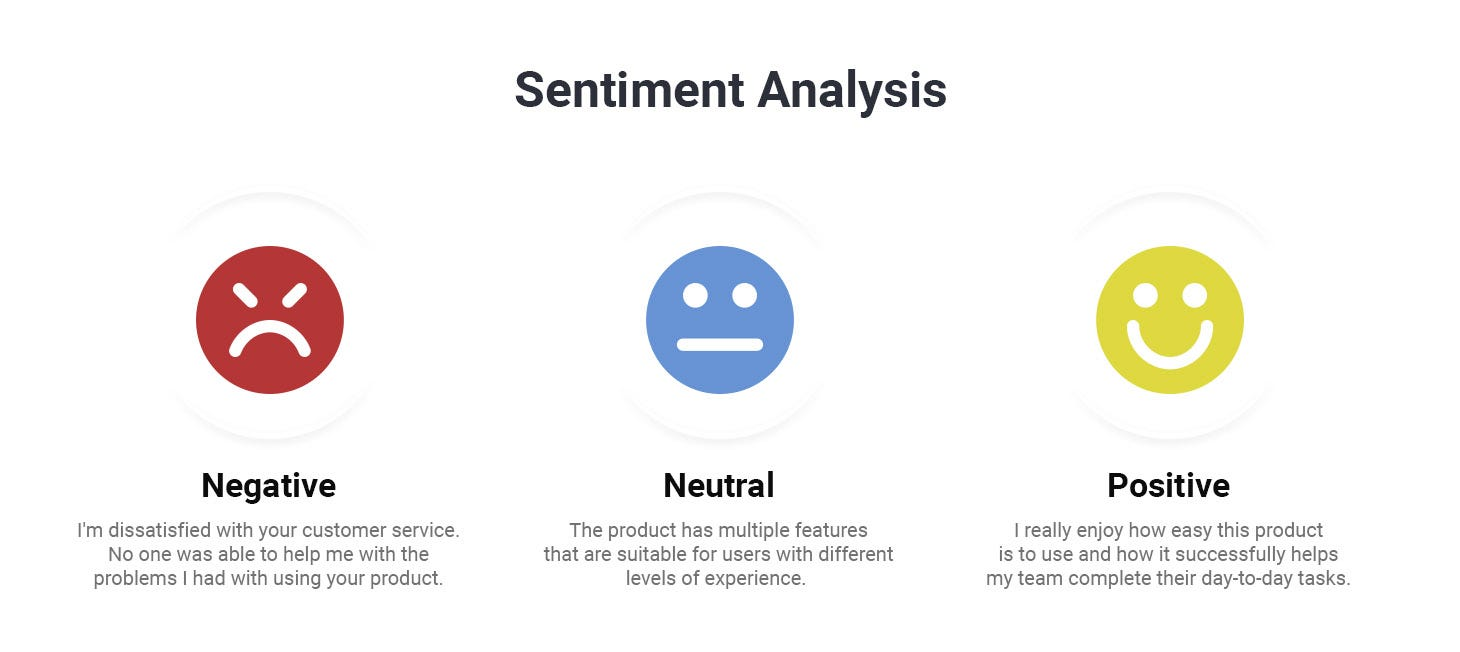

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [ ]:
# Load the dataset
import pandas as pd

data = pd.read_csv('DisneylandReviews.csv', encoding='latin-1')
data

In [ ]:
#Check for missing values
data.isna().sum()

In [ ]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [ ]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

In [ ]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [ ]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

---
## Task 1: Load the data and apply 5 preprocessing steps

Dataset: `Amazon_Unlocked_Mobile.csv` (413,840 reviews). Ratings are mapped to sentiment exactly as in the Disneyland example (>3 positive, <3 negative, 3 neutral).

In [24]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
# nltk.download('stopwords')   # uncomment on first run

amazon = pd.read_csv('Amazon_Unlocked_Mobile.csv')
print('Raw shape:', amazon.shape)
amazon.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Raw shape: (413840, 6)


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [25]:
# Map star ratings to sentiments
amazon = amazon.dropna(subset=['Reviews', 'Rating'])
amazon['Sentiment'] = amazon['Rating'].apply(
    lambda r: 'positive' if r > 3 else ('negative' if r < 3 else 'neutral'))

# Preprocessing step 1: remove duplicate reviews (the dataset repeats many reviews across listings)
before = len(amazon)
amazon = amazon.drop_duplicates(subset=['Reviews'])
print(f'Step 1 - removed {before - len(amazon)} duplicate reviews, {len(amazon)} remain')

stop_words = set(stopwords.words('english'))

def preprocess_review(text):
    text = str(text).lower()                       # Step 2: lowercase
    text = re.sub(r'<.*?>', ' ', text)             # Step 3: remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  #         and URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # Step 4: remove punctuation, digits, special characters
    words = text.split()                           # Step 5: tokenize, then remove stopwords
    words = [w for w in words if w not in stop_words and len(w) > 1]
    return ' '.join(words)

amazon['Clean_Review'] = amazon['Reviews'].apply(preprocess_review)

# drop reviews that became empty after cleaning
amazon = amazon[amazon['Clean_Review'].str.len() > 0].reset_index(drop=True)
print('Final shape:', amazon.shape)
print(amazon['Sentiment'].value_counts())
amazon[['Reviews', 'Clean_Review', 'Sentiment']].head()

Step 1 - removed 251280 duplicate reviews, 162490 remain
Final shape: (162281, 8)
Sentiment
positive    103622
negative     44306
neutral      14353
Name: count, dtype: int64


,Reviews,Clean_Review,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone us used hard phone...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but i...,works good goes slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive


## Task 2: Train / test split

80/20 split, **stratified** so that all three classes keep the same proportions in both sets (the data is imbalanced).

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    amazon['Clean_Review'], amazon['Sentiment'],
    test_size=0.2, random_state=42, stratify=amazon['Sentiment'])

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 129824
Test size:  32457


## Task 3: Feature extraction using TF-IDF

The vectorizer is fitted on the **training set only**, then applied to the test set, so no test information leaks into the features.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix (train):', X_train_tfidf.shape)
print('TF-IDF matrix (test): ', X_test_tfidf.shape)

TF-IDF matrix (train): (129824, 5000)
TF-IDF matrix (test):  (32457, 5000)


## Task 4: Train a Naive Bayes classifier

In [28]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
print('Model trained.')

Model trained.


## Task 5: Evaluate the model on the test set

In [29]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = nb_model.predict(X_test_tfidf)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.8114

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.71      0.75      8861
     neutral       0.29      0.02      0.04      2871
    positive       0.82      0.96      0.89     20725

    accuracy                           0.81     32457
   macro avg       0.63      0.57      0.56     32457
weighted avg       0.77      0.81      0.77     32457



## Task 6: Confusion matrix

Confusion matrix (rows = actual, columns = predicted):
          negative  neutral  positive
negative      6332       69      2460
neutral        911       60      1900
positive       701       81     19943


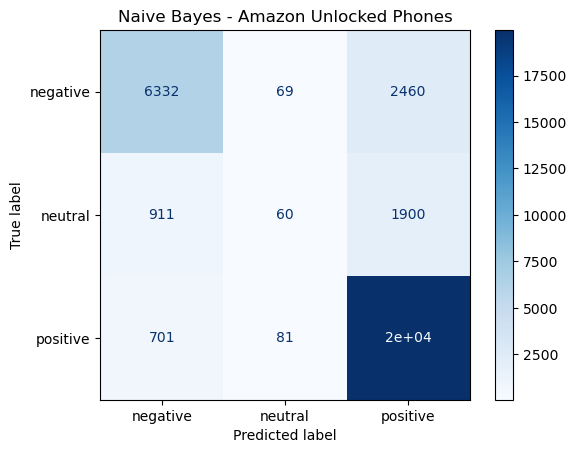

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print('Confusion matrix (rows = actual, columns = predicted):')
print(pd.DataFrame(cm, index=labels, columns=labels))

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues')
plt.title('Naive Bayes - Amazon Unlocked Phones')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

- Overall accuracy is high (~81%), but this is driven by the **majority class**: about 64% of the reviews are positive, so a model that mostly says "positive" already scores well.
- **Positive** (recall ~0.96) and **negative** (recall ~0.71) are handled reasonably well.
- **Neutral** (3-star) reviews are almost never predicted (recall ~0.02). They are the rarest class (~9%) and their wording mixes positive and negative cues, so Naive Bayes has little signal to separate them. The confusion matrix shows most neutral reviews are labelled positive or negative.
- Possible improvements: class weighting / resampling, bigrams in TF-IDF, or a stronger classifier (e.g. logistic regression, linear SVM).